# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Shafira Nabila Noer Poerwanto
- **Email:** cdcc284d6x2715@student.devacademy.id
- **ID Dicoding:** shafiranabila096

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana tren pertumbuhan total penyewaan sepeda secara bulanan (Month-over-Month) sepanjang tahun 2012 jika dibandingkan dengan tahun 2011, guna merencanakan target penambahan kapasitas armada sepeda di tahun depan?
- Pertanyaan 2: Pada jam berapakah rata-rata volume penyewaan sepeda mencapai puncaknya (rush hour) khusus pada hari kerja (workingday) selama Kuartal ke-4 (Bulan Oktober - Desember) tahun 2012, agar tim operasional dapat menetapkan jadwal maintenance rutin tanpa mengganggu pelanggan?

## Import Semua Packages/Library yang Digunakan

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [47]:
day_df=pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [48]:
hour_df=pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset day_df berisi data penyewaan sepeda dengan granularitas harian, sehingga setiap baris merepresentasikan satu hari. Dataset ini memuat informasi waktu seperti musim, tahun, bulan, hari libur, hari kerja, serta kondisi cuaca seperti suhu, kelembapan, dan kecepatan angin. Selain itu, terdapat variabel utama berupa jumlah pengguna casual, registered, dan total penyewaan (cnt) yang menjadi indikator utama performa bisnis harian.
- Dataset hour_df memiliki struktur kolom yang hampir sama dengan day_df, namun dengan tingkat detail yang lebih tinggi karena setiap baris merepresentasikan data per jam. Hal ini ditunjukkan dengan adanya kolom tambahan hr yang menunjukkan jam penyewaan dari 0 hingga 23. Dataset ini sangat berguna untuk menganalisis pola penggunaan sepeda secara intrahari, seperti identifikasi jam sibuk, perilaku komuter, dan fluktuasi permintaan sepanjang hari.

### Assessing Data

#### Data `day_df`

In [49]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [50]:
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [51]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


#### Data `hour_df`

In [52]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [53]:
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [54]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Dataset memiliki kualitas yang baik karena tidak terdapat missing values dan duplikasi, sehingga data dapat langsung digunakan tanpa proses pembersihan yang kompleks
- Variabel dalam dataset didominasi oleh tipe numerik, yang memudahkan proses analisis statistik maupun pemodelan, namun kolom tanggal masih perlu dikonversi agar analisis berbasis waktu lebih maksimal
- Tersedianya dua level data yaitu harian dan per jam memberikan fleksibilitas analisis, sehingga pola permintaan dapat dikaji baik secara umum maupun lebih detail berdasarkan waktu

### Cleaning Data

#### Data `day_df`

##### Menghapus Data duplikat

In [55]:
day_df.duplicated().sum()
day_df.drop_duplicates(inplace=True)
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


##### Menghapus Missing values

In [56]:
day_df = hour_df.dropna()
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

##### Menghapus kolom 'instant' karena hanya berupa nomor urut

In [57]:
day_df.drop('instant', axis=1, inplace=True)

##### Mengubah tipe data 'dteday' menjadi datetime

In [58]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

##### Melabeli Ulang Data (Mapping Kategori)

In [59]:
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weekday_mapping = {0: 'Minggu', 1: 'Senin', 2: 'Selasa', 3: 'Rabu', 4: 'Kamis', 5: 'Jumat', 6: 'Sabtu'}
weather_mapping = {1: 'Cerah/Sebagian Berawan', 2: 'Kabut/Berawan', 3: 'Salju Ringan/Hujan', 4: 'Hujan Lebat/Badai'}

day_df['season'] = day_df['season'].map(season_mapping)
day_df['weekday'] = day_df['weekday'].map(weekday_mapping)
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)

##### Membuat kolom 'day_type' (Hari Kerja vs Libur)

In [60]:
day_df['day_type'] = day_df['workingday'].apply(lambda x: 'Hari Kerja' if x == 1 else 'Akhir Pekan/Libur')

##### Mengubah Format Tanggal menjadi DD-MM-YYYY

In [61]:
# day_df['dteday'] = day_df['dteday'].dt.strftime('%d-%m-%Y')

##### Ekstraksi tahun dan bulan untuk mempermudah filter Time-bound

In [62]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
day_df['year'] = day_df['dteday'].dt.year
day_df['month'] = day_df['dteday'].dt.month

##### Menampilkan data

In [63]:
day_df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,day_type,year,month
0,2011-01-01,Spring,0,1,0,0,Sabtu,0,Cerah/Sebagian Berawan,0.24,0.2879,0.81,0.0,3,13,16,Akhir Pekan/Libur,2011,1
1,2011-01-01,Spring,0,1,1,0,Sabtu,0,Cerah/Sebagian Berawan,0.22,0.2727,0.80,0.0,8,32,40,Akhir Pekan/Libur,2011,1
2,2011-01-01,Spring,0,1,2,0,Sabtu,0,Cerah/Sebagian Berawan,0.22,0.2727,0.80,0.0,5,27,32,Akhir Pekan/Libur,2011,1
3,2011-01-01,Spring,0,1,3,0,Sabtu,0,Cerah/Sebagian Berawan,0.24,0.2879,0.75,0.0,3,10,13,Akhir Pekan/Libur,2011,1
4,2011-01-01,Spring,0,1,4,0,Sabtu,0,Cerah/Sebagian Berawan,0.24,0.2879,0.75,0.0,0,1,1,Akhir Pekan/Libur,2011,1


#### Data `hour_df`

##### Mengahapus data duplikat

In [64]:
hour_df.duplicated().sum()
hour_df.drop_duplicates(inplace=True)
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


##### Menghapus Missing values

In [65]:
hour_df = hour_df.dropna()
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

##### Menghapus kolom 'instant' karena hanya berupa nomor urut

In [66]:
hour_df.drop('instant', axis=1, inplace=True)

##### Mengubah tipe data 'dteday' menjadi datetime

In [67]:
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

##### Melabeli Ulang Data (Mapping Kategori)

In [68]:
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weekday_mapping = {0: 'Minggu', 1: 'Senin', 2: 'Selasa', 3: 'Rabu', 4: 'Kamis', 5: 'Jumat', 6: 'Sabtu'}
weather_mapping = {1: 'Cerah/Sebagian Berawan', 2: 'Kabut/Berawan', 3: 'Salju Ringan/Hujan', 4: 'Hujan Lebat/Badai'}

hour_df['season'] = hour_df['season'].map(season_mapping)
hour_df['weekday'] = hour_df['weekday'].map(weekday_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

##### Membuat kolom 'day_type' (Hari Kerja vs Libur)

In [69]:
hour_df['day_type'] = hour_df['workingday'].apply(lambda x: 'Hari Kerja' if x == 1 else 'Akhir Pekan/Libur')

##### Mengubah Format Tanggal menjadi DD-MM-YYYY

In [70]:
# hour_df['dteday'] = hour_df['dteday'].dt.strftime('%d-%m-%Y')

##### Ekstraksi tahun dan bulan untuk mempermudah filter Time-bound

In [71]:
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
hour_df['year'] = hour_df['dteday'].dt.year
hour_df['month'] = hour_df['dteday'].dt.month

##### Menampilkan data

In [72]:
hour_df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,day_type,year,month
0,2011-01-01,Spring,0,1,0,0,Sabtu,0,Cerah/Sebagian Berawan,0.24,0.2879,0.81,0.0,3,13,16,Akhir Pekan/Libur,2011,1
1,2011-01-01,Spring,0,1,1,0,Sabtu,0,Cerah/Sebagian Berawan,0.22,0.2727,0.80,0.0,8,32,40,Akhir Pekan/Libur,2011,1
2,2011-01-01,Spring,0,1,2,0,Sabtu,0,Cerah/Sebagian Berawan,0.22,0.2727,0.80,0.0,5,27,32,Akhir Pekan/Libur,2011,1
3,2011-01-01,Spring,0,1,3,0,Sabtu,0,Cerah/Sebagian Berawan,0.24,0.2879,0.75,0.0,3,10,13,Akhir Pekan/Libur,2011,1
4,2011-01-01,Spring,0,1,4,0,Sabtu,0,Cerah/Sebagian Berawan,0.24,0.2879,0.75,0.0,0,1,1,Akhir Pekan/Libur,2011,1


**Insight:**
- Data `day_df`: Data harian menjadi lebih bersih dan konsisten setelah penghapusan duplikasi, missing values, dan kolom yang tidak relevan. Selain itu, pelabelan ulang kategori, perubahan format tanggal, serta penambahan kolom day_type membuat data lebih mudah dipahami dan siap untuk analisis pola harian.
- Data `hour_df`: Data per jam juga menjadi lebih rapi dan terstruktur setelah proses cleaning yang sama, sehingga setiap jam pengamatan lebih akurat. Penyesuaian format tanggal, relabeling, dan penambahan day_type membantu analisis yang lebih detail berdasarkan waktu dan jenis hari.

## Exploratory Data Analysis (EDA)

### Matriks Korelasi (Faktor Numerik vs Total Pengguna)

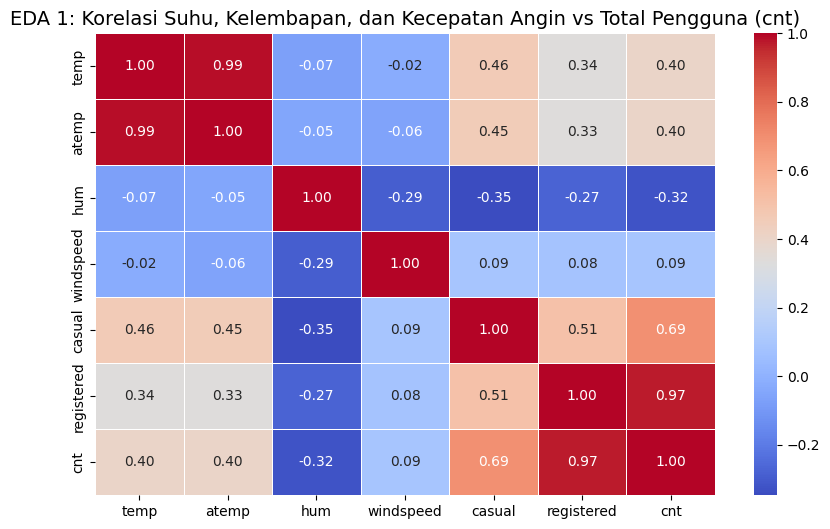

In [73]:
plt.figure(figsize=(10, 6))
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr_matrix = day_df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('EDA 1: Korelasi Suhu, Kelembapan, dan Kecepatan Angin vs Total Pengguna (cnt)', fontsize=14)
plt.show()

### Pengaruh Musim terhadap Jumlah Pengguna (Bar Chart)

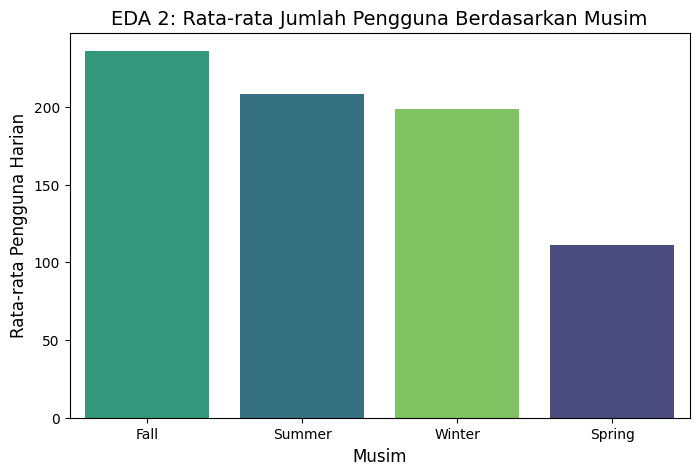

In [74]:
plt.figure(figsize=(8, 5))
season_order = day_df.groupby('season')['cnt'].mean().sort_values(ascending=False).index

sns.barplot(
    data=day_df, x='season', y='cnt', order=season_order, hue='season',     
    palette='viridis', errorbar=None, legend=False          
)

plt.title('EDA 2: Rata-rata Jumlah Pengguna Berdasarkan Musim', fontsize=14)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Rata-rata Pengguna Harian', fontsize=12)

plt.show()

### Pengaruh Kondisi Cuaca terhadap Jumlah Pengguna (Boxplot)

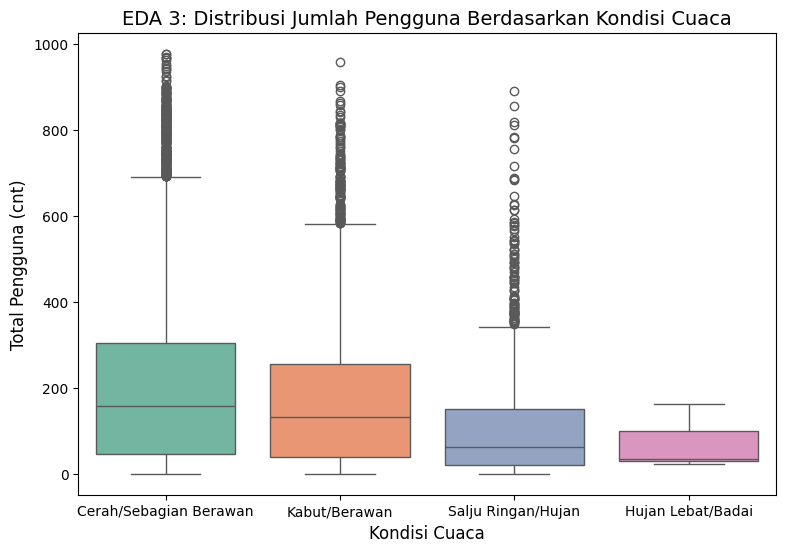

In [75]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=day_df, x='weathersit', y='cnt', palette='Set2', hue='weathersit', legend=False)
plt.title('EDA 3: Distribusi Jumlah Pengguna Berdasarkan Kondisi Cuaca', fontsize=14)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Total Pengguna (cnt)', fontsize=12)
plt.show()

**Insight:**
- Heatmap menunjukkan bahwa total penyewaan didominasi pengguna terdaftar (0.97), sementara pengguna kasual juga berkontribusi (0.69) namun lebih dipengaruhi cuaca; suhu meningkatkan penggunaan (0.40), kelembapan menurunkan (-0.32), dan angin tidak signifikan.
- Rata-rata penyewaan sepeda tertinggi terjadi pada musim Fall, diikuti Summer dan Winter, sementara Spring paling rendah, menunjukkan bahwa penggunaan cenderung meningkat pada musim dengan cuaca lebih nyaman dan stabil, serta menurun pada musim yang kurang mendukung aktivitas bersepeda.
- Boxplot menunjukkan bahwa jumlah pengguna sepeda paling tinggi dan variatif terjadi saat cuaca cerah/berawan, menurun pada kondisi berkabut/berawan, semakin rendah saat hujan ringan/salju, dan paling sedikit saat hujan lebat/badai; ini menegaskan bahwa semakin buruk kondisi cuaca, semakin rendah minat pengguna untuk menyewa sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren pertumbuhan total penyewaan sepeda secara bulanan (Month-over-Month) sepanjang tahun 2012 jika dibandingkan dengan tahun 2011, guna merencanakan target penambahan kapasitas armada sepeda di tahun depan?

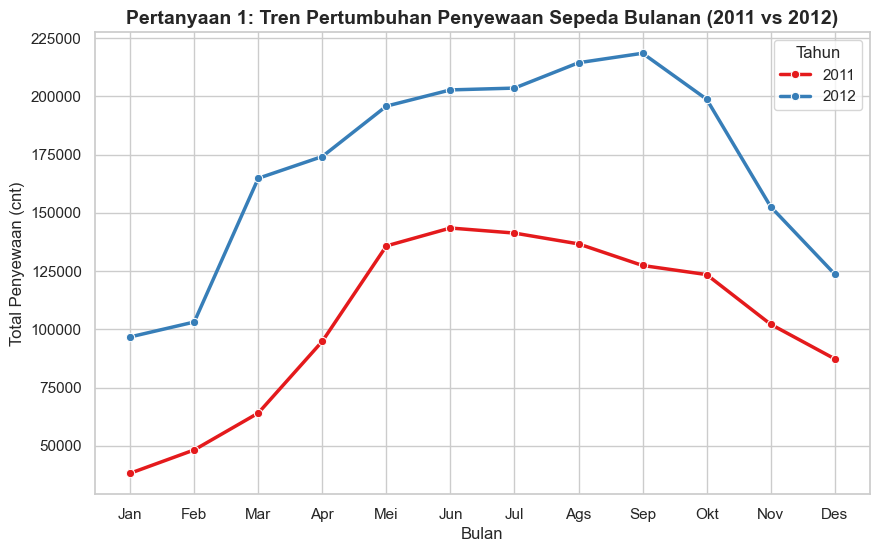

In [78]:
sns.set_theme(style="whitegrid")
monthly_trend = day_df.groupby(['year', 'month'])['cnt'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_trend, x='month', y='cnt', hue='year', marker='o', palette='Set1', linewidth=2.5)
plt.title('Pertanyaan 1: Tren Pertumbuhan Penyewaan Sepeda Bulanan (2011 vs 2012)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Penyewaan (cnt)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des'])
plt.legend(title='Tahun')
plt.show()

### Pertanyaan 2: Pada jam berapakah rata-rata volume penyewaan sepeda mencapai puncaknya (rush hour) khusus pada hari kerja (workingday) selama Kuartal ke-4 (Bulan Oktober - Desember) tahun 2012, agar tim operasional dapat menetapkan jadwal maintenance rutin tanpa mengganggu pelanggan?

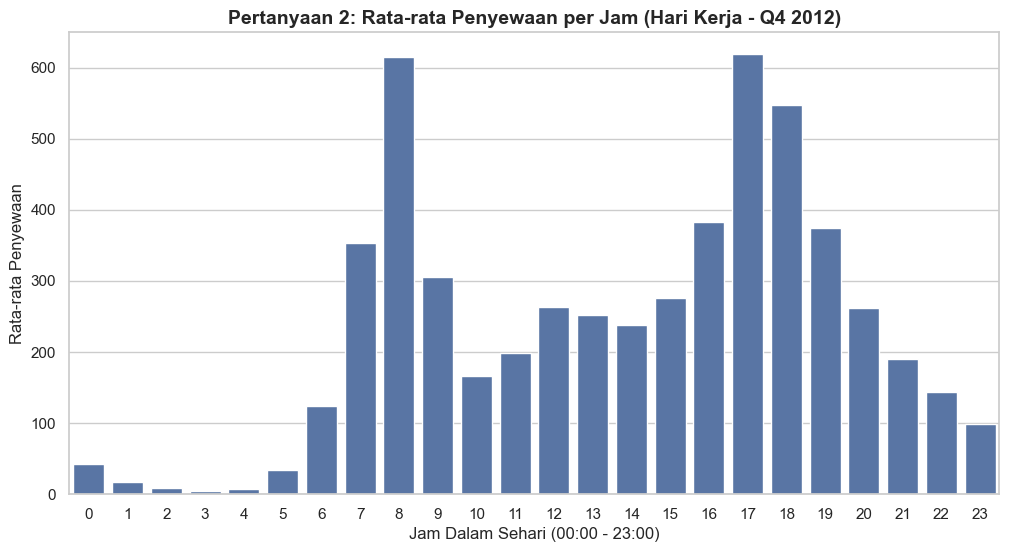

In [85]:
q4_2012_workdays = hour_df[(hour_df['year'] == 2012) & 
                           (hour_df['month'].isin([10, 11, 12])) & 
                           (hour_df['workingday'] == 1)]

hourly_q4 = q4_2012_workdays.groupby('hr')['cnt'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_q4, x='hr', y='cnt', color='#4C72B0')
plt.title('Pertanyaan 2: Rata-rata Penyewaan per Jam (Hari Kerja - Q4 2012)', fontsize=14, fontweight='bold')
plt.xlabel('Jam Dalam Sehari (00:00 - 23:00)', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.show()

**Insight:**
- Tren Bulanan Penyewaan Sepeda (2011 vs 2012): 
Jumlah penyewaan sepeda pada tahun 2012 selalu lebih tinggi dibandingkan tahun 2011 di setiap bulan. Kedua tahun menunjukkan pola musiman yang serupa, yaitu permintaan rendah pada awal tahun, meningkat secara bertahap hingga mencapai puncak pada bulan Agustus–September, kemudian kembali menurun menjelang akhir tahun.
- Pola Jam Sibuk pada Hari Kerja Q4 2012
Penyewaan sepeda pada hari kerja membentuk pola bimodal dengan dua puncak utama, yaitu pada pukul 08.00 pagi serta pukul 17.00–18.00 sore. Sebaliknya, aktivitas penyewaan berada pada titik terendah pada rentang tengah malam hingga dini hari.

## Analisis Lanjutan (Opsional)

### Metode yang Digunakan: Clustering (Binning)

In [81]:
day_df['demand_category'] = pd.qcut(day_df['cnt'], q=3, labels=['Low Demand', 'Medium Demand', 'High Demand'])

high_demand_days = day_df[day_df['demand_category'] == 'High Demand']
weather_on_high_demand = high_demand_days['weathersit'].value_counts().reset_index()
weather_on_high_demand.columns = ['weathersit', 'total_days']

print("Karakteristik Cuaca saat High Demand:")
print(weather_on_high_demand)

Karakteristik Cuaca saat High Demand:
               weathersit  total_days
0  Cerah/Sebagian Berawan        4188
1           Kabut/Berawan        1361
2      Salju Ringan/Hujan         210


Text(0.5, 1.0, 'Proporsi Kategori Permintaan Harian')

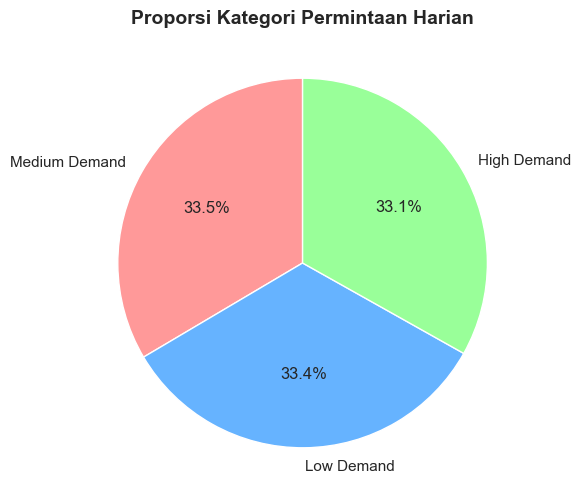

In [82]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
demand_counts = day_df['demand_category'].value_counts()
plt.pie(demand_counts, labels=demand_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
plt.title('Proporsi Kategori Permintaan Harian', fontsize=14, fontweight='bold')

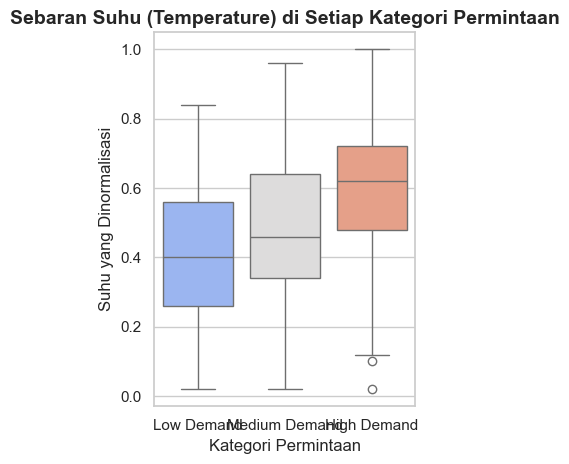

In [83]:
plt.subplot(1, 2, 2)
sns.boxplot(data=day_df, x='demand_category', y='temp', palette='coolwarm',hue='demand_category', legend=False)
plt.title('Sebaran Suhu (Temperature) di Setiap Kategori Permintaan', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Permintaan', fontsize=12)
plt.ylabel('Suhu yang Dinormalisasi', fontsize=12)

plt.tight_layout()
plt.show()

**Insight:**
- Pembagian kategori menggunakan metode clustering (binning) menghasilkan distribusi data yang seimbang antara Low, Medium, dan High Demand sehingga analisis menjadi lebih representatif dan tidak condong ke satu kelompok tertentu
- Hasil pengelompokan menunjukkan bahwa cuaca dan suhu berpengaruh terhadap permintaan, di mana kategori High Demand lebih sering terjadi saat cuaca cerah dan suhu lebih tinggi
- Clustering membantu menyederhanakan data permintaan yang awalnya berupa angka menjadi kategori yang lebih mudah dipahami sehingga pola perilaku pengguna dapat terlihat dengan lebih jelas

### Menyimpan Data 

In [84]:
day_df.to_csv("final_cleaned_day.csv", index=False)
hour_df.to_csv("final_cleaned_hour.csv", index=False)

print("Data berhasil disimpan!")
print("file 'final_cleaned_day.csv' dan 'final_cleaned_hour.csv' sudah tersimpan")

Data berhasil disimpan!
file 'final_cleaned_day.csv' dan 'final_cleaned_hour.csv' sudah tersimpan


## Conclusion

- Conclution pertanyaan 1:
Bisnis penyewaan sepeda menunjukkan pertumbuhan yang signifikan dari tahun 2011 ke 2012 dengan pola permintaan musiman yang konsisten, di mana penyewaan mencapai puncak pada pertengahan tahun dan menurun pada awal serta akhir tahun. Oleh karena itu, perusahaan perlu menyiapkan penambahan serta distribusi armada sebelum memasuki musim puncak, terutama pada bulan April atau Mei, serta menjalankan program promosi khusus pada periode permintaan rendah untuk menjaga stabilitas pendapatan sepanjang tahun.
- Conclution pertanyaan 2:
Pola penyewaan pada hari kerja menunjukkan bahwa sepeda lebih banyak dimanfaatkan sebagai sarana transportasi komuter, ditandai dengan lonjakan permintaan pada pagi hari serta sore hari saat jam berangkat dan pulang kerja. Untuk mendukung kebutuhan tersebut, aktivitas pemeliharaan dan redistribusi sepeda sebaiknya dilakukan di luar jam sibuk, khususnya pada malam hingga dini hari, serta menambah staf operasional pada jam puncak agar ketersediaan unit dan kualitas layanan tetap terjaga.